In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np

print(os.getcwd())

/home/samo/repos/prankdock/source


In [11]:
results_dir = '../output/tunnel_results'

In [68]:
results = {}
upper_bound_hits = {}
lower_bound_hits = {}
for dat_file in glob.glob(f'{results_dir}/*/*/*_energy_profile.dat'):
    table = pd.read_csv(dat_file, sep=' ', names=['distance', 1, 2, 'upper_bound', 5, 'lower_bound'], dtype=float)
    ligand = os.path.basename(os.path.dirname(dat_file)).removeprefix('docking_')
    protein = os.path.basename(os.path.dirname(os.path.dirname(dat_file)))

    if not protein in results:
        results[protein] = {}
        upper_bound_hits[protein] = {}
        lower_bound_hits[protein] = {}
    results[protein][ligand] = table
    upper_bound_hits[protein][ligand] = (table['upper_bound'] < 0).all()
    lower_bound_hits[protein][ligand] = (table['lower_bound'] < 0).all()

In [77]:
# Some ligands were not finished - assume nothing changed for them
upper_df = pd.DataFrame.from_dict(upper_bound_hits).fillna(True)
lower_df = pd.DataFrame.from_dict(lower_bound_hits).fillna(True)



# Filtering results

A crude filtering of ligands based on whether they have at least one energy measurement above zero on their path through the tunnel. 

- Yellow == no positive energy values along the path
- Purple == at least 1 positive value



### Energy values taken from the upper bound energy estimate

Text(0, 0.5, 'Ligand')

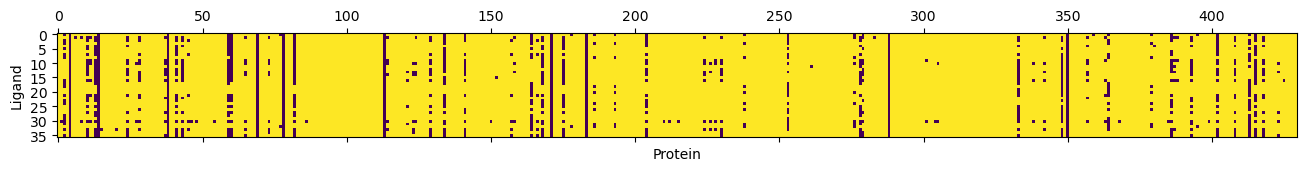

In [78]:
plt.matshow(upper_df.to_numpy().astype(np.bool))
plt.xlabel('Protein')
plt.ylabel('Ligand')

### Energy values taken from the lower bound energy estimate

Text(0, 0.5, 'Ligand')

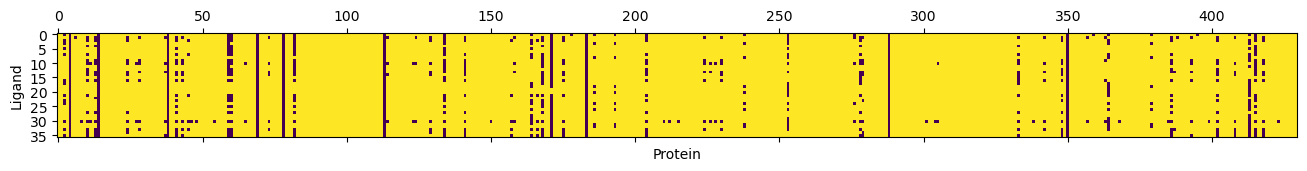

In [79]:
plt.matshow(lower_df.to_numpy().astype(np.bool))
plt.xlabel('Protein')
plt.ylabel('Ligand')

Most of the tunnels allow almost every ligand. Some of them do not, which indicates we hit a tunnel that is not easy to get through. Some proteins do not allow any ligands - tunnel is likely incorrect.

In [80]:
informative_prots_lb = lower_df.columns[lower_df.apply(lambda x: ~x.all(), axis=0)]
informative_prots_ub = upper_df.columns[upper_df.apply(lambda x: ~x.all(), axis=0)]

print('Proteins with at least some filtered results (upper bound energies):')
print(" ".join([prot for prot in informative_prots_ub]))

print('Proteins with at least some filtered results (lower bound energies):')
print(" ".join([prot for prot in informative_prots_lb]))

Proteins with at least some filtered results (upper bound energies):
Q965R6 O44573 O17230 Q18729 Q7Z2B2 Q18570 O17010 O44533 O18690 Q19419 P90821 Q95PY3 Q18568 O17809 Q23073 Q5F4V2 Q21705 Q20882 Q5CCI4 O44639 O16981 Q21715 Q18398 O44660 Q8ITZ7 O45300 G5ECI0 P91504 P91506 Q5F4V5 O45308 Q21767 A0A131MCW1 O61898 Q21786 Q19549 Q23625 O16921 Q22547 O17826 P46570 O17124 O44700 Q94072 Q19026 Q95QP1 Q17781 P90954 Q22383 O01609 O45735 O17358 O45893 O45280 O45774 O45832 O02132 Q9GS08 G5EBQ4 Q18766 G5EF54 Q17943 O17633 Q966G6 O45803 O44542 O17701 Q966G9 O01468 O16278 Q23041 O61881 Q09344 Q5F4U8 O45353 P90760 Q8IFX9 O01608 Q18929 Q7YWP3 O62384 Q18552 Q20961 O01890 Q19321 Q94048 O17238 O16980 G3MU24 O17877 O45461 Q95X80 Q18807 Q19897 Q95XW0 Q17975 O16990
Proteins with at least some filtered results (lower bound energies):
O44573 O17230 Q18729 Q7Z2B2 Q18570 O17010 O44533 O18690 Q95PY3 Q18568 O17809 Q23073 Q5F4V2 Q21705 Q20882 Q5CCI4 O44639 O16981 Q21715 Q18398 O44660 Q8ITZ7 O45300 G5ECI0 P91506 Q5F4

# Compute new best ligands for proteins with at least some filtered results

In [98]:
new_results = {}
for prot in informative_prots_ub:
    valid_ligands = list(results[prot].keys())
    valid_ligands = [ligand for ligand in valid_ligands if ligand in set(upper_df.index[upper_df[prot]])]
    if len(valid_ligands) == 0:
        print(f'{prot}: Tunnel allows no ligands')
    new_results[prot] = {}
    for ligand in results[prot]:
        # Take the energy at site
        new_results[prot][ligand] = {}
        new_results[prot][ligand]['upper_bound'] = results[prot][ligand].iloc[0]['upper_bound']
        new_results[prot][ligand]['lower_bound'] = results[prot][ligand].iloc[0]['lower_bound']
    
    df = pd.DataFrame.from_dict(new_results[prot]).T.sort_values('upper_bound')
    df.index.name = 'ligand'
    new_results[prot] = df

O17230: Tunnel allows no ligands
O18690: Tunnel allows no ligands
Q5F4V2: Tunnel allows no ligands
O45300: Tunnel allows no ligands
P91506: Tunnel allows no ligands
Q21767: Tunnel allows no ligands
Q17781: Tunnel allows no ligands
O01609: Tunnel allows no ligands
O45735: Tunnel allows no ligands
G5EF54: Tunnel allows no ligands
Q966G9: Tunnel allows no ligands
P90760: Tunnel allows no ligands
G3MU24: Tunnel allows no ligands


In [100]:
os.makedirs('../output/new_filtered_results', exist_ok=True)
for prot in new_results:
    new_results[prot].to_csv(f'../output/new_filtered_results/{prot}.csv')